In [2]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd


In [26]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'n_cs_vs_K_parameter_swipe'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


run = '20250826-103447'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)




In [9]:
final_abundance_data = data['all_N_final']
final_resource_data = data['all_R_final']
all_C = {f'C_{i}{j}': data[f'C_{i}{j}'] for i in range(final_abundance_matrix.shape[0]) for j in range(final_abundance_matrix.shape[1])}

In [ ]:
final_abundance_matrix = np.zeros((args.N_cs, args.N_K_std, args.N_Csp, args.iterations, 4))
counter = 0
for i in range(args.N_cs):
    for j in range(args.N_K_std):
        for k in range(args.N_Csp):
            final_abundance_matrix[i,j,k,:,:] = final_abundance_data[counter]
            counter += 1
            

In [14]:
richness_matrix = (final_abundance_matrix > 1e-6).sum(axis=4).mean(axis=3)
median_richness = np.median((final_abundance_matrix > 1e-6).sum(axis=4), axis=3)

# Make variable lists from args


In [16]:

n_cs_arr = np.linspace(args.cs_min, args.cs_max, num=args.N_cs, dtype=int, endpoint = True)
K_std_arr = np.linspace(args.K_std_min, args.K_std_max, num = args.N_K_std, endpoint = True)
c_arr = np.linspace(args.csp_min, args.csp_max, num = args.N_Csp, endpoint = True)


In [54]:
richness_matrix[-1,-1,:]

array([3.25, 3.6 , 3.6 ])

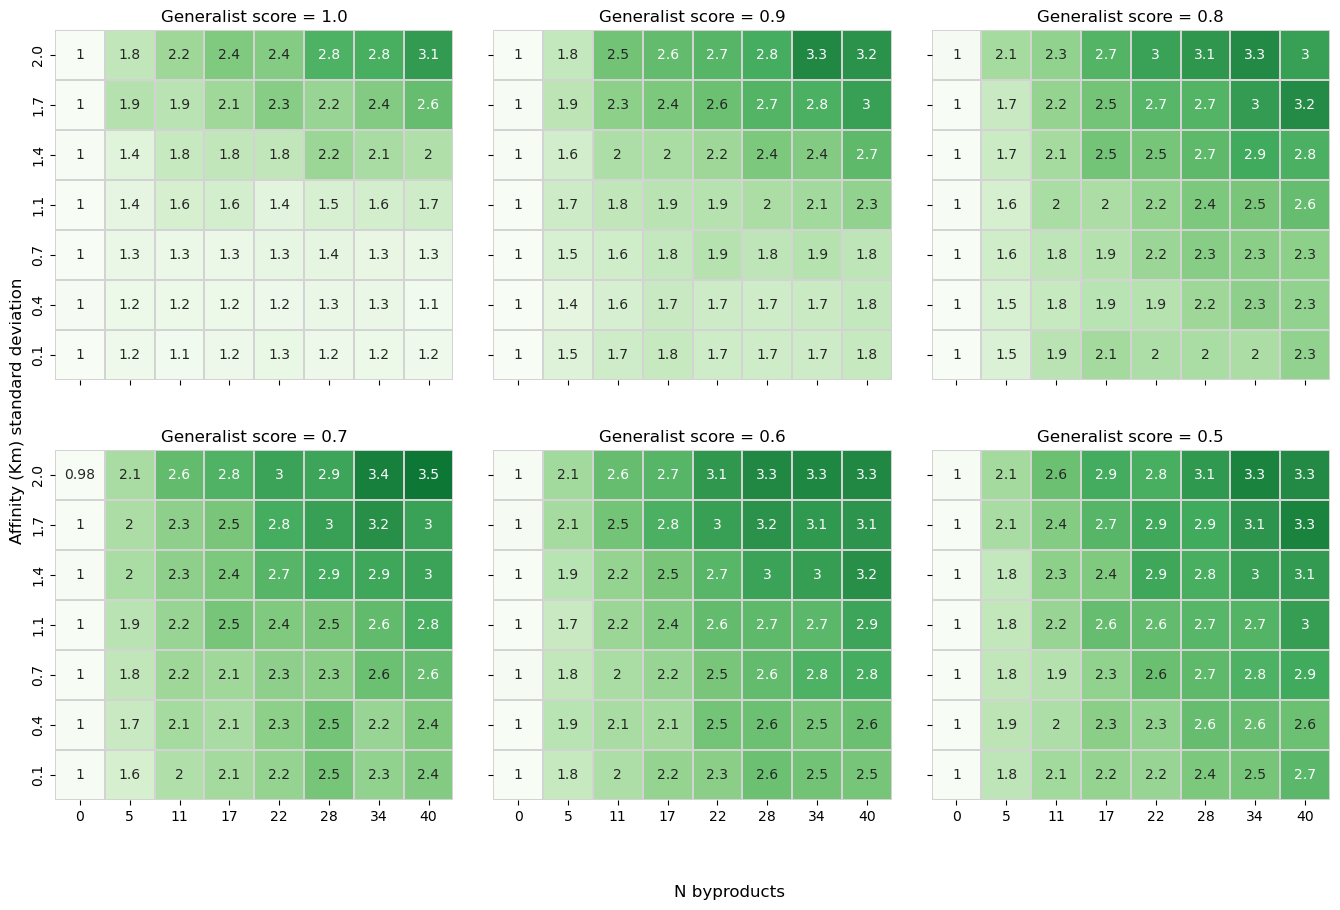

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(args.N_Csp):
    ax = axes[i]
    ax.set_title(f'Generalist score = {1 - c_arr[i]:.1f}')
    sns.heatmap(richness_matrix[:,::-1,i].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = False,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
fig.supylabel('Affinity (Km) standard deviation')
fig.supxlabel('N byproducts')
plt.subplots_adjust(left=0.05, wspace = 0.1)
# plt.title('Richness on single carbon source with 4 species community')

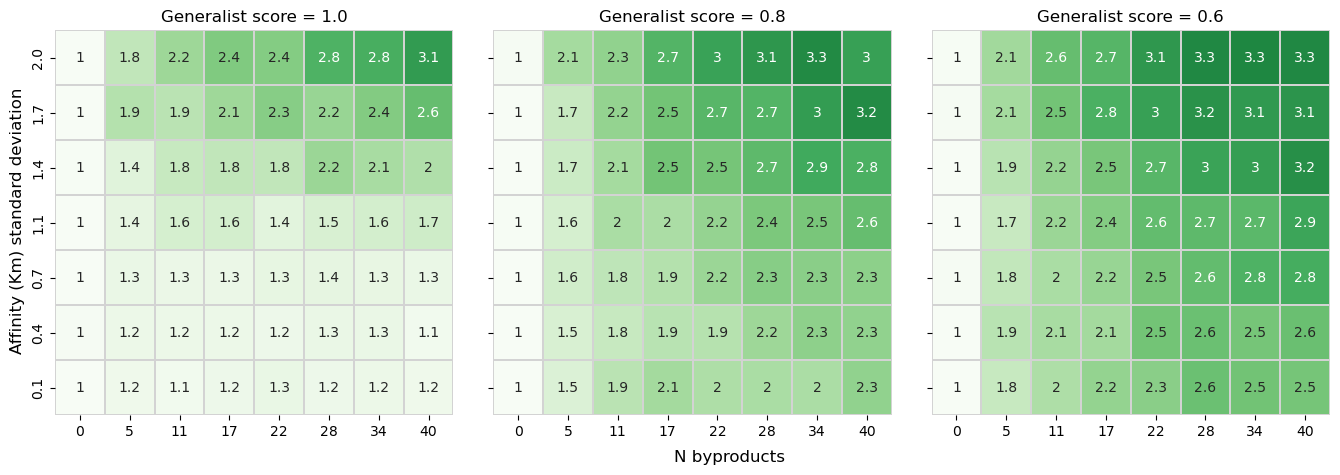

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
axes = axes.flatten()
for i,j in enumerate([0, 2, 4]):
    ax = axes[i]
    ax.set_title(f'Generalist score = {1 - c_arr[j]:.1f}')
    sns.heatmap(richness_matrix[:,::-1,j].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = False,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
fig.supylabel('Affinity (Km) standard deviation')
fig.supxlabel('N byproducts')
plt.subplots_adjust(left=0.05, wspace = 0.1)
# plt.title('Richness on single carbon source with 4 species community')
plt.savefig(figure_folder / f'20250826_richness_heatmap.pdf', bbox_inches='tight')

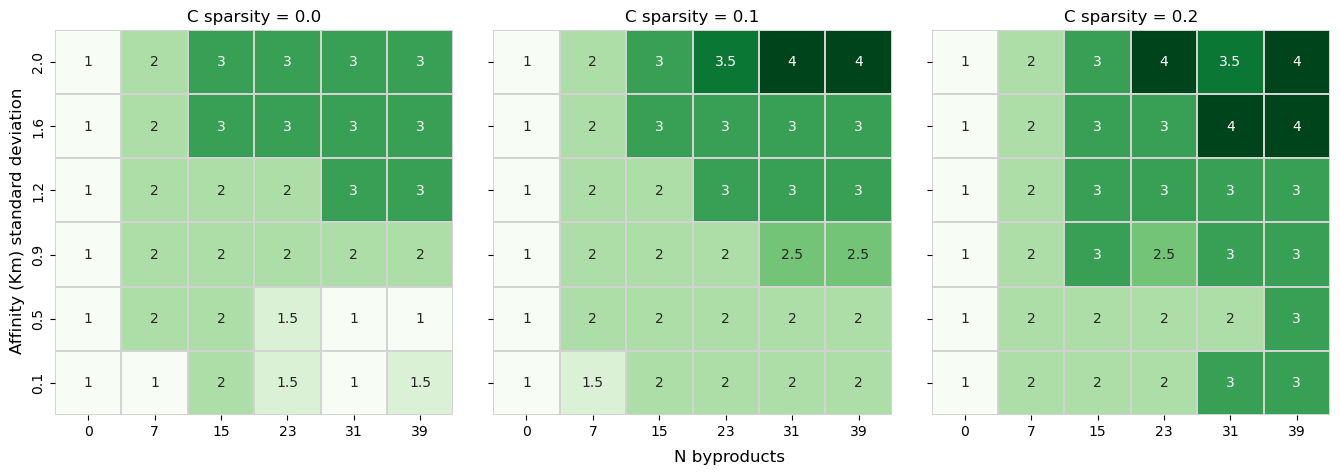

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for i in range(3):
    ax = axes[i]
    ax.set_title(f'C sparsity = {c_arr[i]:.1f}')
    sns.heatmap(median_richness[:,::-1,i].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = False,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
fig.supylabel('Affinity (Km) standard deviation')
fig.supxlabel('N byproducts')
plt.subplots_adjust(left=0.05, wspace = 0.1)
# plt.title('Richness on single carbon source with 4 species community')

Text(20.72222222222222, 0.5, 'Affinity (Km) standard deviation')

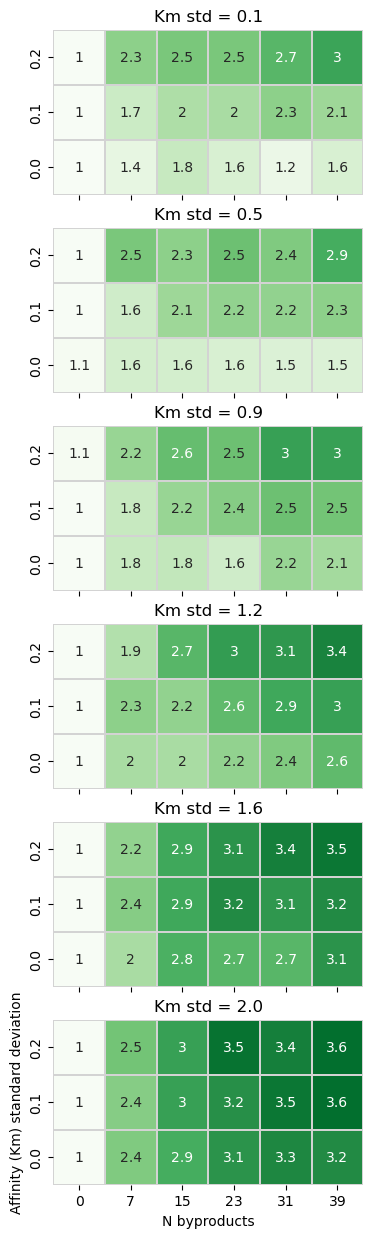

In [84]:
fig, axes = plt.subplots(6, 1, figsize=(4, 15), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(6):
    ax = axes[i]
    ax.set_title(f'Km std = {K_std_arr[i]:.1f}')
    sns.heatmap(richness_matrix[:,i,::-1].T, 
                yticklabels=[f'{x:.1f}' for x in c_arr][::-1],
                cmap='Greens',
                cbar = False,
                # cbar_kws={'label':'Mean richness'}, 
                # xticklabels = np.linspace(2, 30, 29, dtype=int)-1,
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='lightgrey', linewidths=0.1, annot=True)
    # )
    plt.xlabel('N byproducts')
plt.ylabel('Affinity (Km) standard deviation')

# plt.title('Richness on single carbon source with 4 species community')

# Plot distributions

In [94]:
# Flatten the abundance matrix
flat = final_abundance_matrix.reshape(
    len(n_cs_arr) * len(K_std_arr) * len(c_arr) * final_abundance_matrix.shape[3], 
    final_abundance_matrix.shape[4]
)

# Create metadata for each row
metadata = []
for i, ncs in enumerate(n_cs_arr):
    for j, kstd in enumerate(K_std_arr):
        for k, csp in enumerate(c_arr):
            for l in range(final_abundance_matrix.shape[3]):  # iterations
                metadata.append((ncs, kstd, csp, l))

# Build DataFrame
abundance_df = pd.DataFrame(flat, columns=[f"species_{i+1}" for i in range(final_abundance_matrix.shape[4])])
abundance_df[['n_cs', 'K_std', 'c_sparsity', 'iteration']] = pd.DataFrame(metadata)

# Optional: set metadata as index
abundance_df.set_index(['n_cs', 'K_std', 'c_sparsity', 'iteration'], inplace=True)
abundance_df.reset_index(inplace=True)

In [99]:
abundance_df['Richness'] = (abundance_df[['species_1', 'species_2', 'species_3', 'species_4']] > 1e-6).sum(axis=1)

In [113]:
(abundance_df['Richness']==0).sum()

np.int64(1)

(0.0, 4.0)

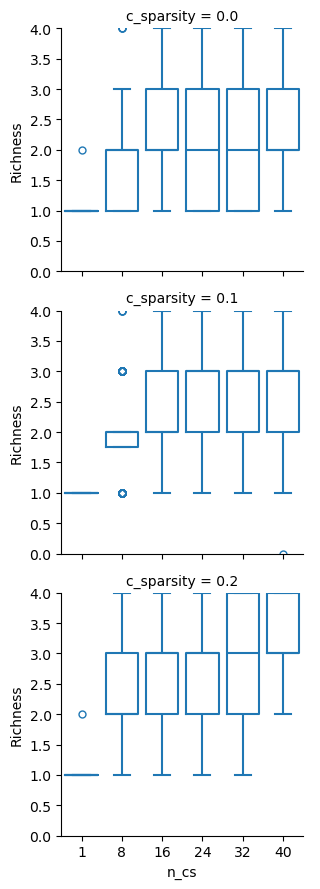

In [120]:

sns.catplot(data = abundance_df, 
            x = 'n_cs', y = 'Richness', 
            # col = 'K_std', 
            row = 'c_sparsity',
            kind = 'box',
            fill = False,
            # inner = None,
            height = 3, aspect = 1,
            sharey = True,
            sharex = True,
            # cut = 0
            )
plt.ylim(0, 4)

(0.0, 4.0)

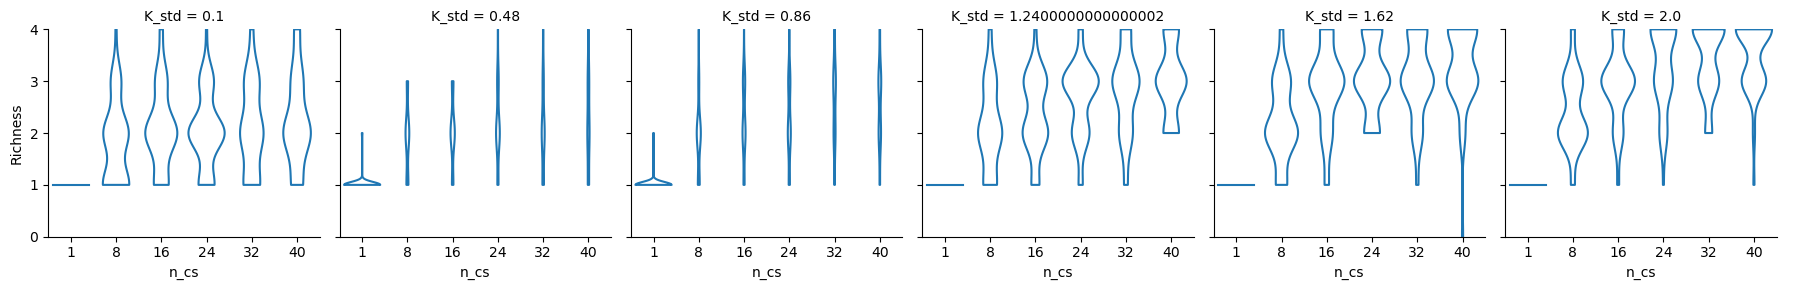

In [116]:

sns.catplot(data = abundance_df, 
            x = 'n_cs', y = 'Richness', 
            col = 'K_std', 
            # row = 'c_sparsity',
            kind = 'violin',
            fill = False,
            inner = None,
            height = 3, aspect = 1,
            sharey = True,
            sharex = True,
            cut = 0
            )
plt.ylim(0, 4)